# Compétition 1 : Prédiction de la Qualité de la Bière 🍺

Ce notebook fournit du code de démarrage pour la compétition de prédiction de la qualité de la bière. Pour les instructions complètes, l'énoncé du problème et les critères de notation, veuillez vous référer au fichier **README.md**.

**Résumé rapide** : Vous allez construire un modèle de classification pour prédire la qualité de la bière (scores 1-10) basé sur des propriétés chimiques. Soumettez vos prédictions sur [Kaggle](https://www.kaggle.com/competitions/ift-6390-ift-3395-beer-quality-prediction/).

## Importer les Dépendances

In [198]:
# Importer les bibliothèques requises
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier, KernelDensity
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

## Charger et Explorer les Données

In [199]:
# Charger les données d'entraînement
train_df = pd.read_csv('data/train.csv', delimiter=';')

print(f"Forme des données d'entraînement : {train_df.shape}")
print(f"Nombre d'échantillons (n) : {train_df.shape[0]}")
print(f"Nombre de caractéristiques (d) : {train_df.shape[1] - 1}")  # Soustraire 1 pour la colonne cible
print(f"Colonnes : {list(train_df.columns)}")
print("\nPremières lignes :")
print(train_df.head())

# Vérifier les types de données et informations de base
print("\nTypes de données et informations :")
print(train_df.info())

####################################################################
###############   À compléter   ####################################
####################################################################

Forme des données d'entraînement : (4469, 15)
Nombre d'échantillons (n) : 4469
Nombre de caractéristiques (d) : 14
Colonnes : ['id', 'beer_style', 'bitterness_IBU', 'diacetyl_concentration', 'lactic_acid', 'final_gravity', 'sodium', 'free_CO2', 'dissolved_oxygen', 'original_gravity', 'pH', 'gypsum_level', 'alcohol_ABV', 'fermentation_strength', 'quality']

Premières lignes :
   id beer_style  bitterness_IBU  diacetyl_concentration  lactic_acid  \
0   0       Pale           7.997                   0.446        0.280   
1   1       Pale           6.906                   0.222        0.303   
2   2      Brown           7.183                   0.636        0.071   
3   3       Pale           6.403                   0.242        0.260   
4   4      Brown           7.917                   0.182        0.347   

   final_gravity  sodium  free_CO2  dissolved_oxygen  original_gravity     pH  \
0         10.803   0.052    24.999           157.026             0.995  3.057   
1          6.305   0.

## Prétraitement des Données

Implémentez votre pipeline de prétraitement (voir README.md pour des suggestions).

NULL VALUES IN train_df 0
id                        0
beer_style                0
bitterness_IBU            0
diacetyl_concentration    0
lactic_acid               0
final_gravity             0
sodium                    0
free_CO2                  0
dissolved_oxygen          0
original_gravity          0
pH                        0
gypsum_level              0
alcohol_ABV               0
fermentation_strength     0
quality                   0
dtype: int64
NULL VALUES IN train_df 0
id                        0
beer_style                0
bitterness_IBU            0
diacetyl_concentration    0
lactic_acid               0
final_gravity             0
sodium                    0
free_CO2                  0
dissolved_oxygen          0
original_gravity          0
pH                        0
gypsum_level              0
alcohol_ABV               0
fermentation_strength     0
quality                   0
dtype: int64


/home/alixloungnarath/miniconda3/envs/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


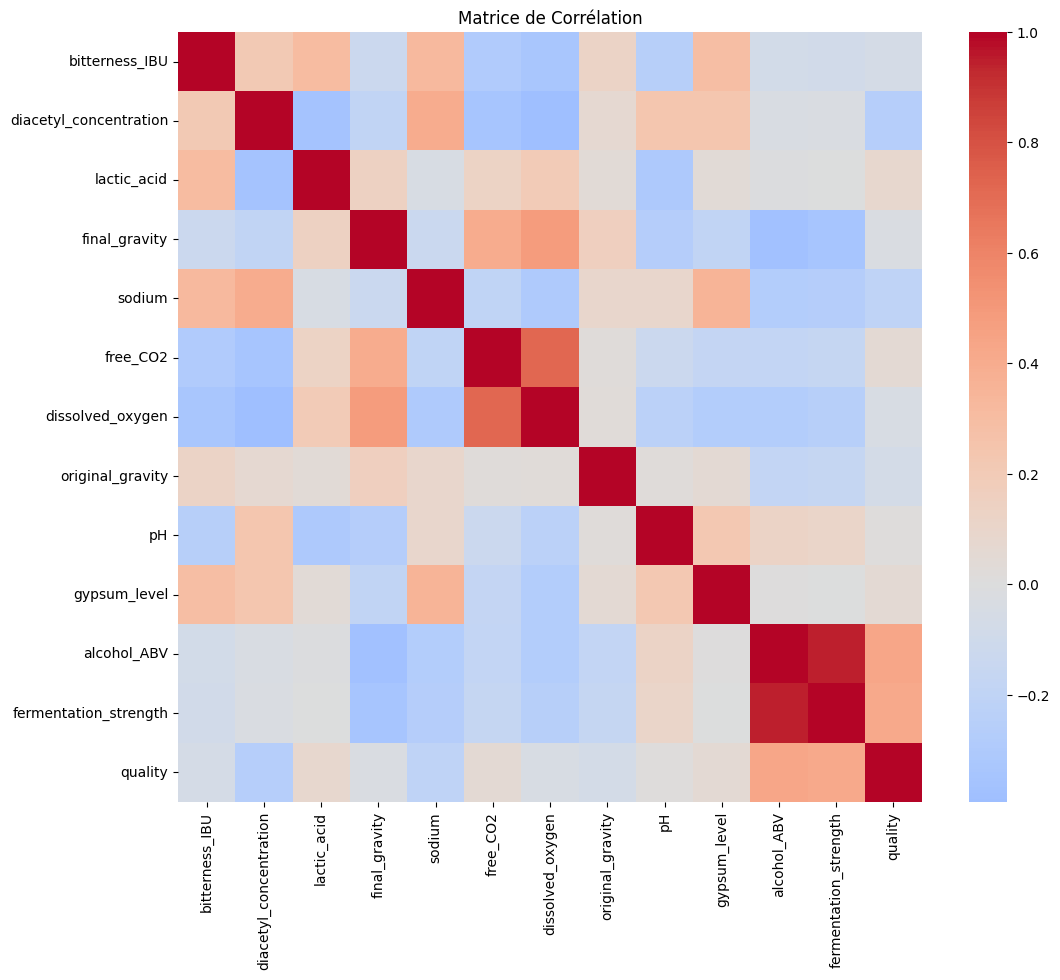

Corrélations avec la qualité :
alcohol_ABV               0.429573
fermentation_strength     0.415413
lactic_acid               0.084929
gypsum_level              0.050566
free_CO2                  0.048208
pH                        0.009651
final_gravity            -0.025002
dissolved_oxygen         -0.043173
bitterness_IBU           -0.066505
original_gravity         -0.070147
sodium                   -0.208010
diacetyl_concentration   -0.258880
Name: quality, dtype: float64


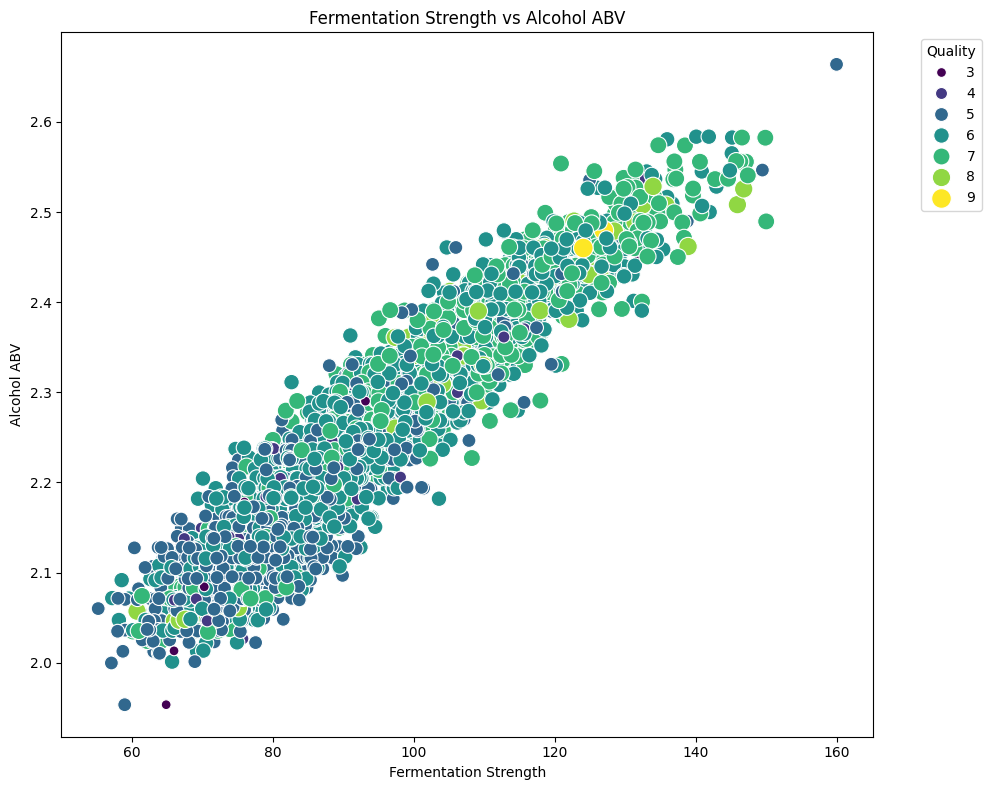

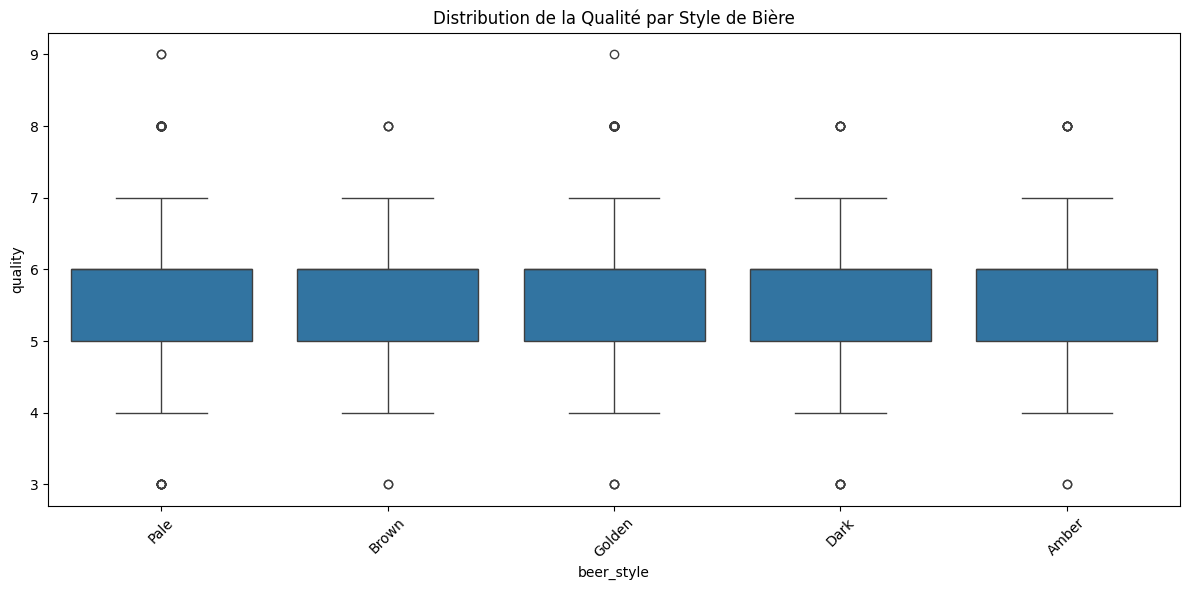

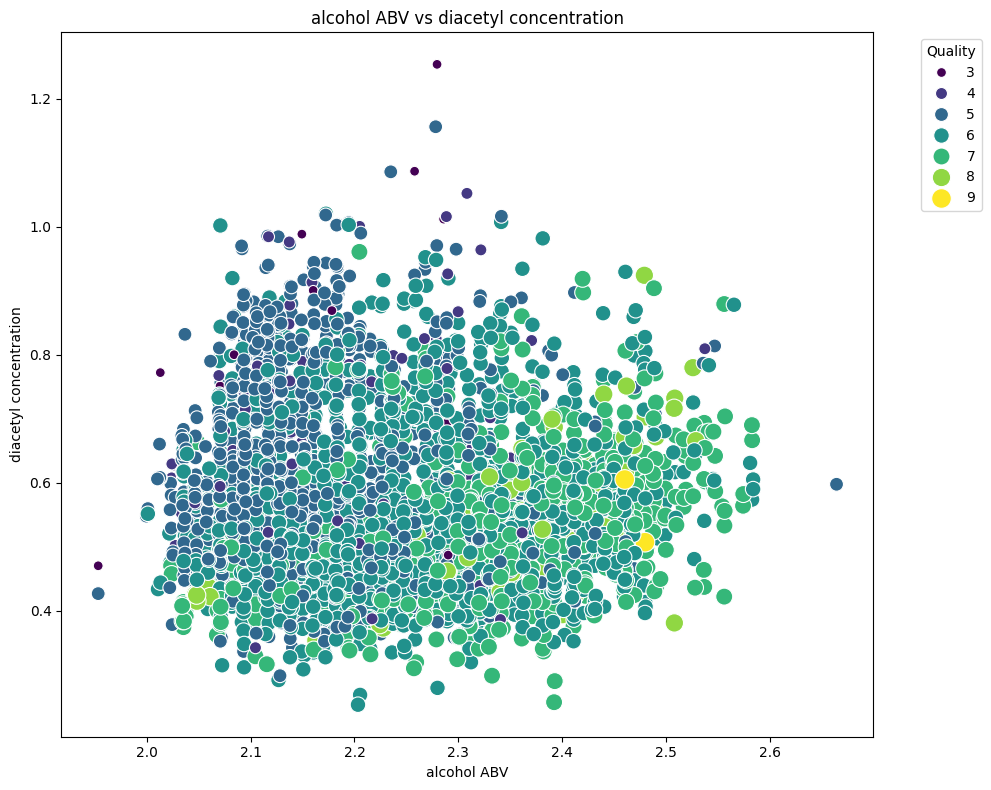

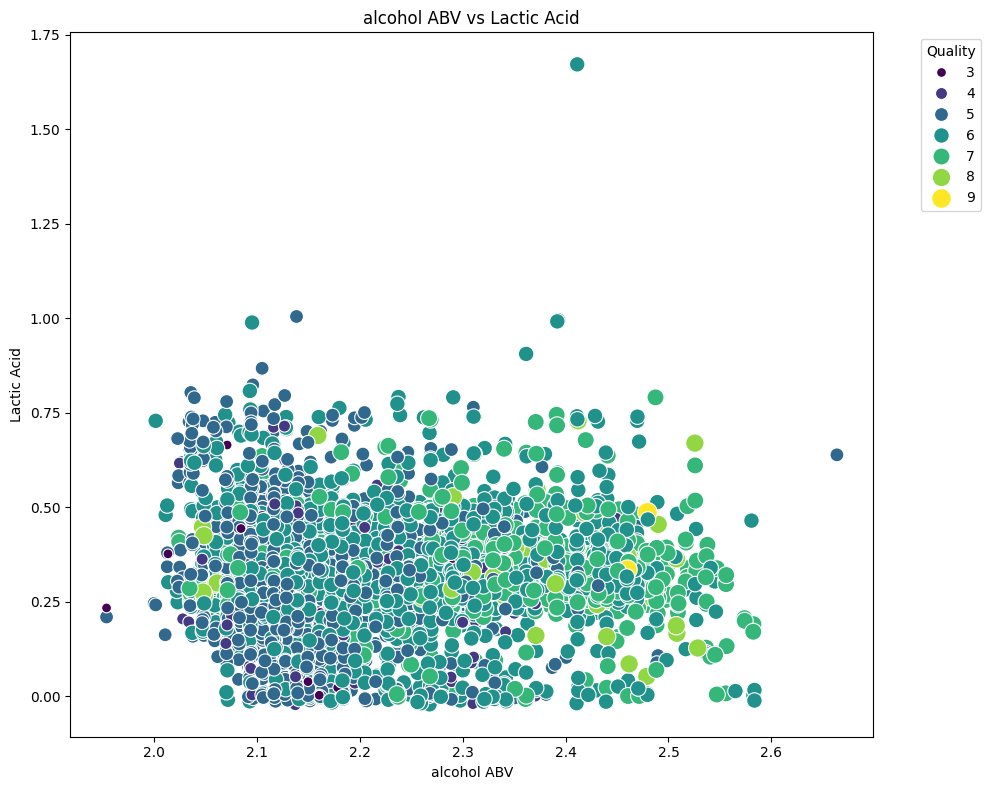

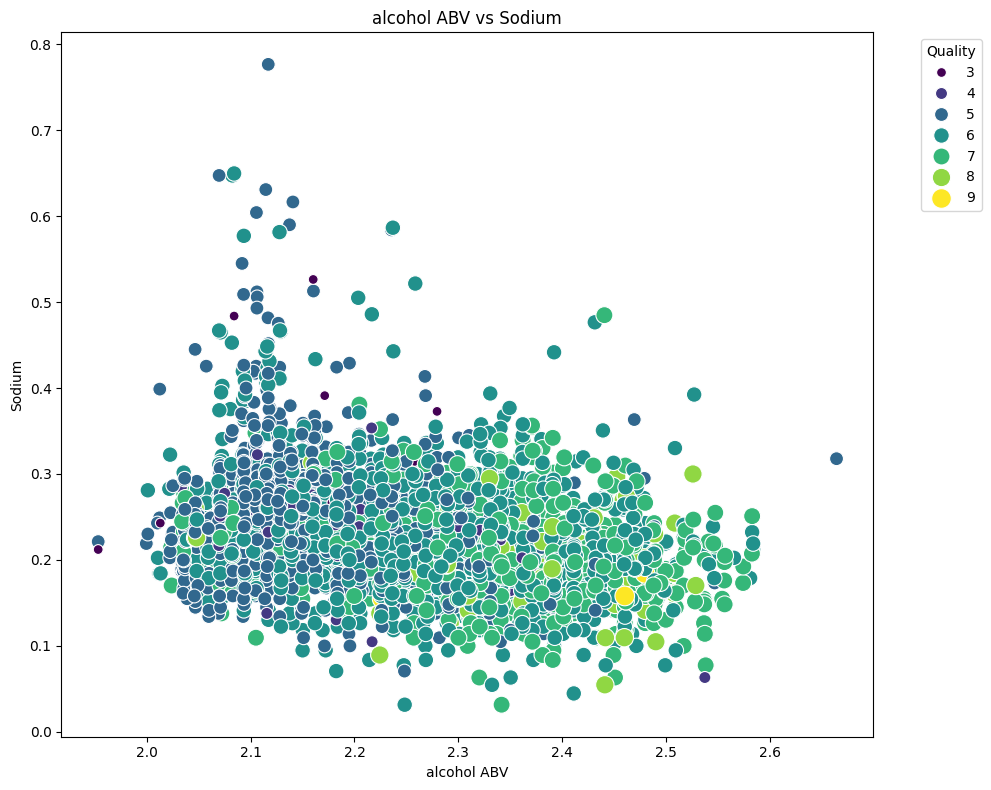

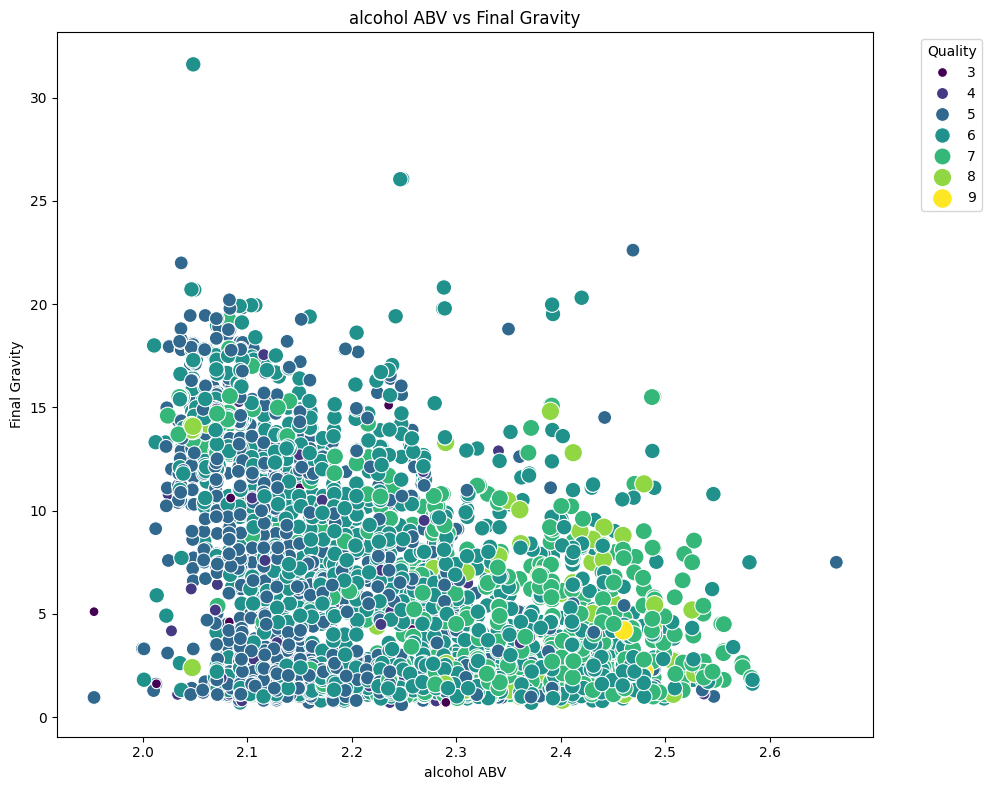

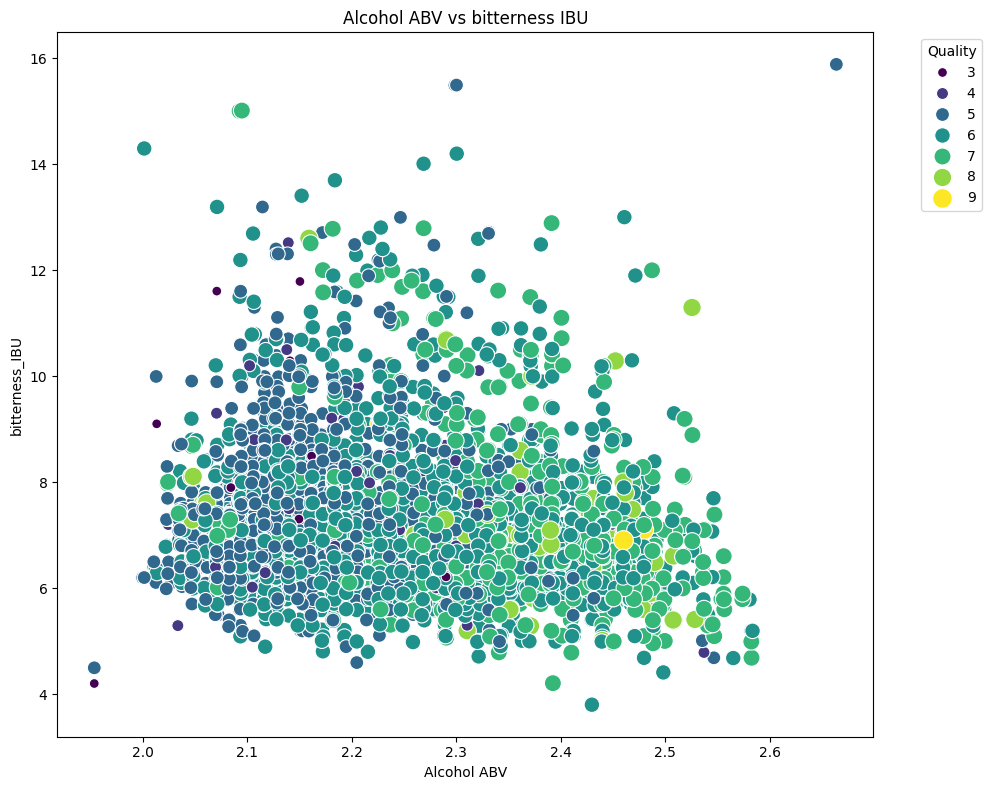

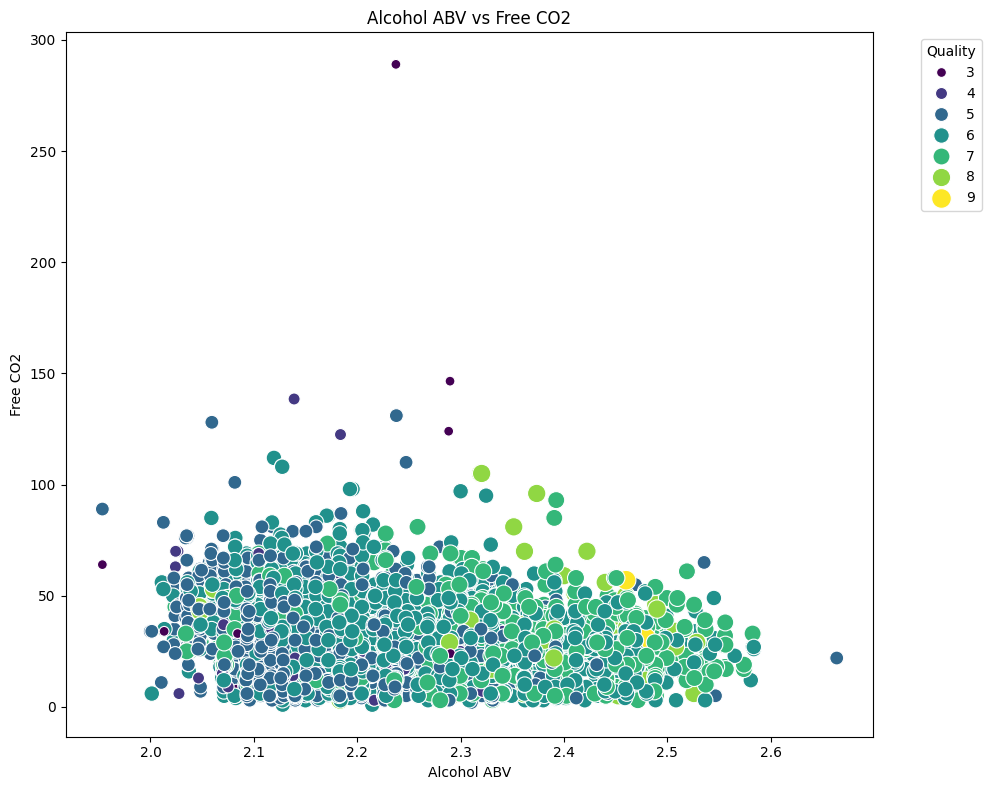

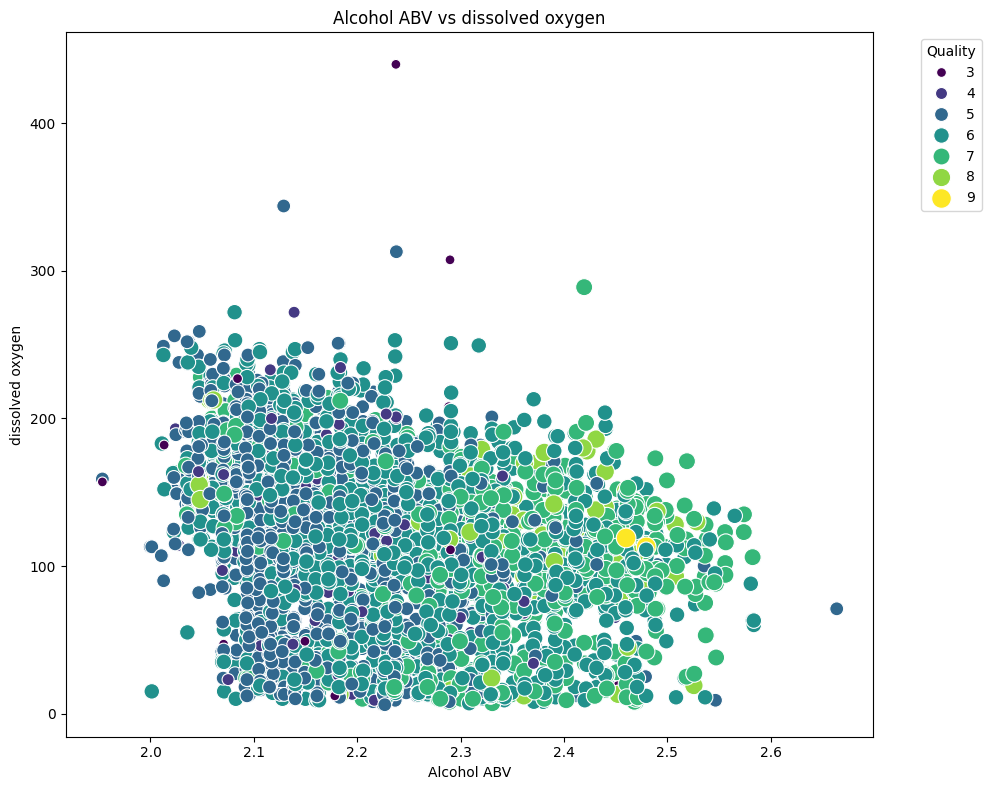

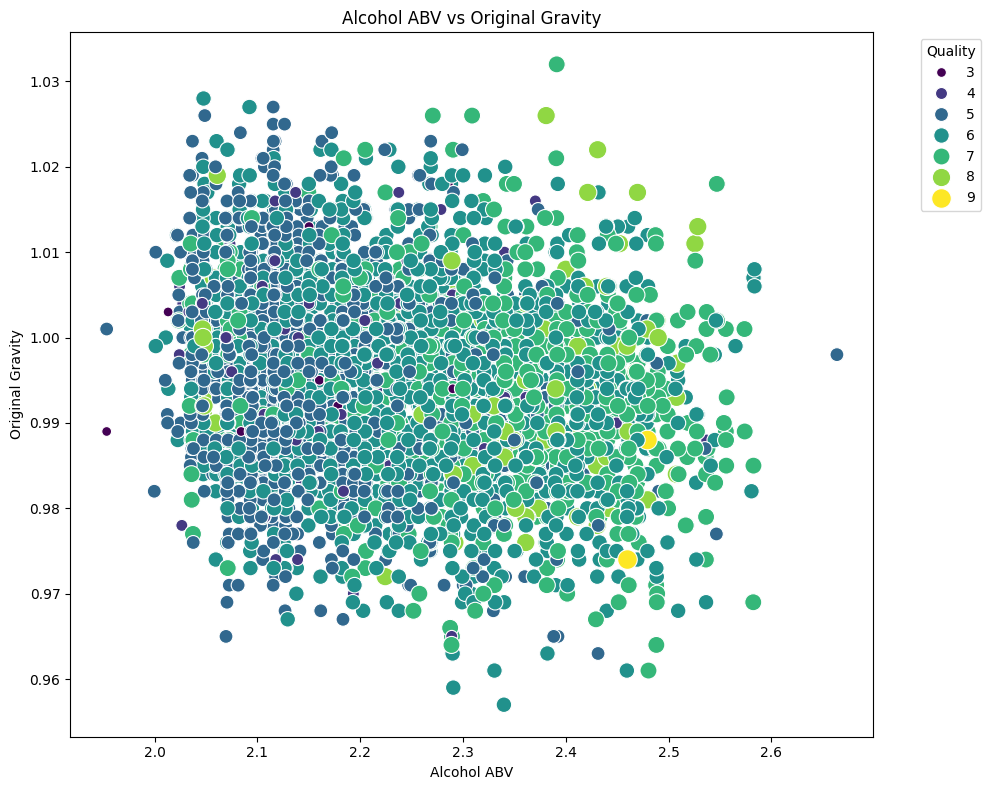

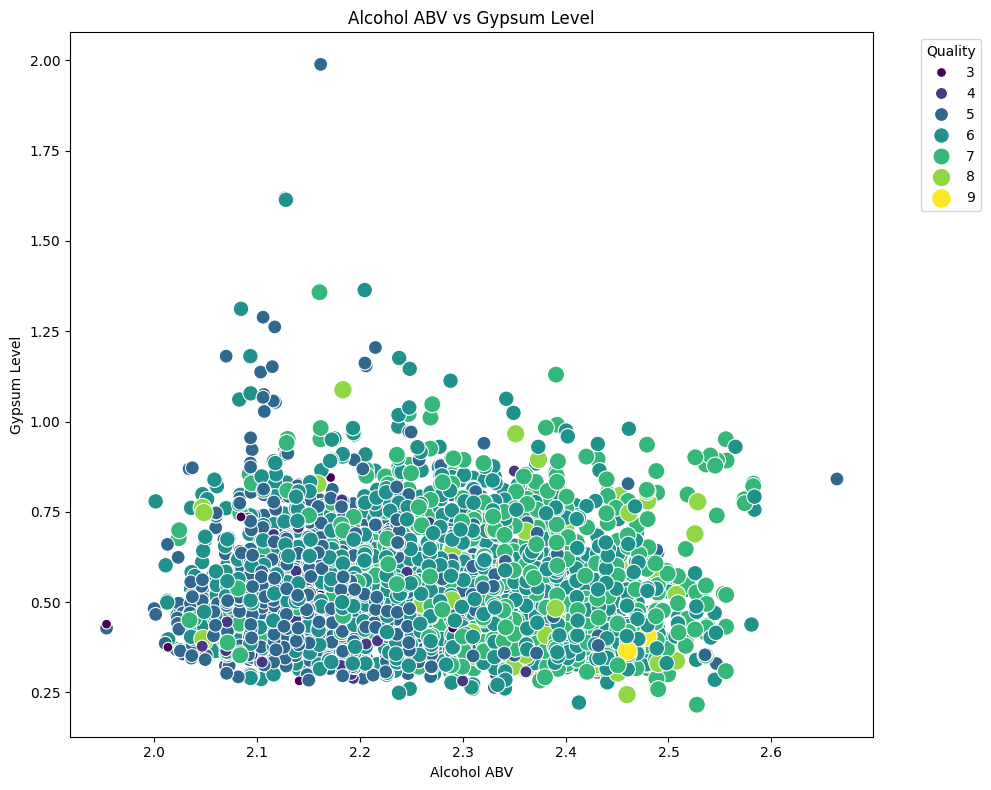

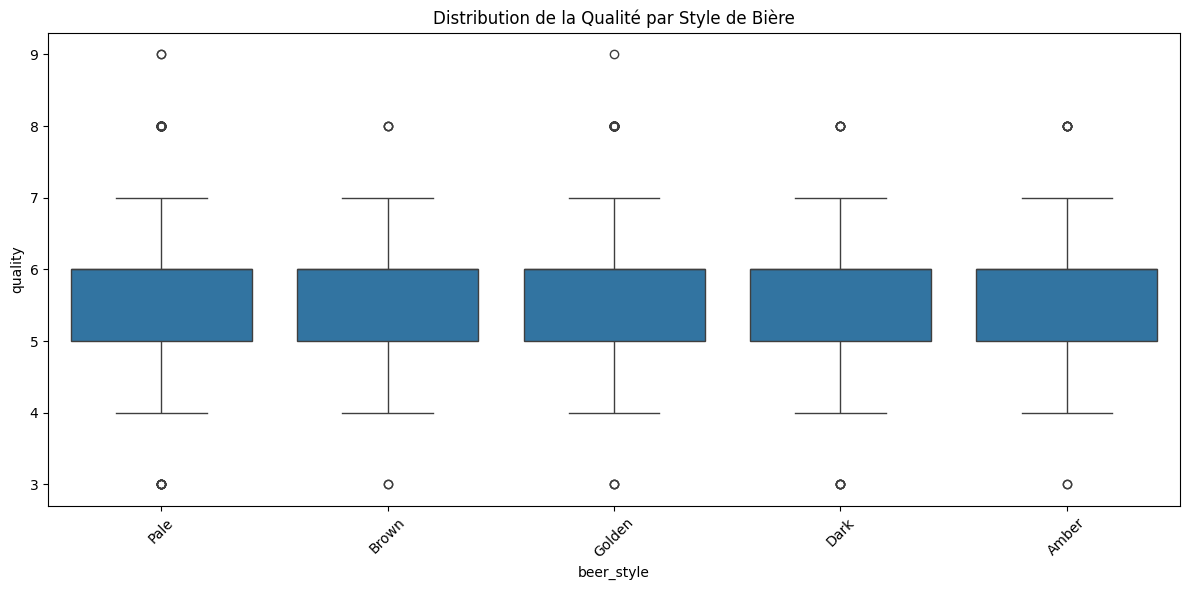

,alcohol_ABV,diacetyl_concentration,sodium,beer_style_Amber,beer_style_Brown,beer_style_Dark,beer_style_Golden,beer_style_Pale
0,0.823819,0.773677,-0.000994,0.0,0.0,0.0,0.0,1.0
1,0.298769,-0.738612,-0.731314,0.0,0.0,0.0,0.0,1.0
2,-0.650289,1.770756,0.916130,0.0,1.0,0.0,0.0,0.0
3,1.625753,-0.578926,-0.346887,0.0,0.0,0.0,0.0,1.0
4,1.231509,-1.081222,0.035522,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
4464,-0.378142,-1.099297,0.416459,0.0,0.0,0.0,1.0,0.0
4465,-0.633389,0.531941,0.974927,1.0,0.0,0.0,0.0,0.0
4466,-0.727484,0.252065,-0.112701,0.0,0.0,0.0,1.0,0.0
4467,0.806496,-1.720263,-0.037863,0.0,0.0,0.0,0.0,1.0


quality
6    1984
5    1496
7     754
4     116
8      93
3      21
9       3
Name: count, dtype: int64


In [200]:
####################################################################
###############   À compléter   ####################################
####################################################################

# Prétraitement des données

train_df = pd.read_csv('data/train.csv', delimiter=';')

# Vérifier le nombre de valeurs manquantes par colonne
print("NULL VALUES IN train_df",train_df.isna().sum().sum())  
print(train_df.isna().sum().sort_values(ascending=False))
# -> 57 valeurs manquantes dans lactic_acid

# 57/4469 = 1,27 % -> on peut se permettre de supprimer
# les lignes avec données manquantes:

train_df = train_df.dropna(subset=['lactic_acid'])

train_df['fermentation_strength'] = (train_df['fermentation_strength'])**2

train_df['alcohol_ABV'] = np.sqrt(train_df['alcohol_ABV'])
train_df['diacetyl_concentration'] = np.sqrt(train_df['diacetyl_concentration'])
train_df['sodium'] = np.sqrt(train_df['sodium'])

train_df = train_df.dropna(subset=['sodium'])


# Division des caractéristiques numériques (On ne prend pas en compte
# les valeurs catégorielles après visualisation graph)
num_cols = ['bitterness_IBU', 'diacetyl_concentration', 'lactic_acid',
                'final_gravity', 'sodium', 'free_CO2', 'dissolved_oxygen',
                'original_gravity', 'pH', 'gypsum_level', 'alcohol_ABV',
                  'fermentation_strength']

print("NULL VALUES IN train_df",train_df.isna().sum().sum())  
print(train_df.isna().sum().sort_values(ascending=False))


# Matrice de corrélation
plt.figure(figsize=(12, 10))
correlation_matrix = train_df[num_cols + ['quality']].corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Matrice de Corrélation')
plt.show()

quality_correlations = correlation_matrix['quality'].drop('quality').sort_values(ascending=False)
print("Corrélations avec la qualité :")
print(quality_correlations)

# QUELQUES VISUALISATIONS
# Visualisation de la relation entre fermentation_strength et alcohol_ABV
plt.figure(figsize=(10, 8))
sns.scatterplot(data=train_df, x='fermentation_strength', y='alcohol_ABV', 
                hue='quality', palette='viridis', size='quality', sizes=(50, 200))
plt.title('Fermentation Strength vs Alcohol ABV')
plt.xlabel('Fermentation Strength')
plt.ylabel('Alcohol ABV')
plt.legend(title='Quality', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
# Linéaire donc redondant?

# Visualisation de la distribution de la qualité par style de bière
plt.figure(figsize=(12, 6))
sns.boxplot(data=train_df, x='beer_style', y='quality')
plt.title('Distribution de la Qualité par Style de Bière')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# On remarque que la distribution de la qualité est la même pour 
# chaque style, on peut donc ne pas prendre en compte cette
# caractéristique

# Graph alcohol ve diacetyle_concentration
plt.figure(figsize=(10, 8))
sns.scatterplot(data=train_df, x='alcohol_ABV', y='diacetyl_concentration', 
                hue='quality', palette='viridis', size='quality', sizes=(50, 200))
plt.title('alcohol ABV vs diacetyl concentration')
plt.xlabel('alcohol ABV')
plt.ylabel('diacetyl concentration')
plt.legend(title='Quality', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
# Aucune conclusion

# Graph dissolbed_oxygen and lactic acid
plt.figure(figsize=(10, 8))
sns.scatterplot(data=train_df, x='alcohol_ABV', y='lactic_acid', 
                hue='quality', palette='viridis', size='quality', sizes=(50, 200))
plt.title('alcohol ABV vs Lactic Acid')
plt.xlabel('alcohol ABV')
plt.ylabel('Lactic Acid')
plt.legend(title='Quality', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
# Aucune conclusion

# Graph diacetyl_concentration and sodium
plt.figure(figsize=(10, 8))
sns.scatterplot(data=train_df, x='alcohol_ABV', y='sodium', 
                hue='quality', palette='viridis', size='quality', sizes=(50, 200))
plt.title('alcohol ABV vs Sodium')
plt.xlabel('alcohol ABV')
plt.ylabel('Sodium')
plt.legend(title='Quality', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
# Aucune conclusion

# Graph original gravity and final gravity
plt.figure(figsize=(10, 8))
sns.scatterplot(data=train_df, x='alcohol_ABV', y='final_gravity', 
                hue='quality', palette='viridis', size='quality', sizes=(50, 200))
plt.title('alcohol ABV vs Final Gravity')
plt.xlabel('alcohol ABV')
plt.ylabel('Final Gravity')
plt.legend(title='Quality', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
# Aucune conclusion

# Graph alcohol ABV ve Bitterness IBU
plt.figure(figsize=(10, 8))
sns.scatterplot(data=train_df, x='alcohol_ABV', y='bitterness_IBU', 
                hue='quality', palette='viridis', size='quality', sizes=(50, 200))
plt.title('Alcohol ABV vs bitterness IBU')
plt.xlabel('Alcohol ABV')
plt.ylabel('bitterness_IBU')
plt.legend(title='Quality', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
# Aucune conclusion

# Graph alcohol ABV vs free CO2
plt.figure(figsize=(10, 8))
sns.scatterplot(data=train_df, x='alcohol_ABV', y='free_CO2', 
                hue='quality', palette='viridis', size='quality', sizes=(50, 200))
plt.title('Alcohol ABV vs Free CO2')
plt.xlabel('Alcohol ABV')
plt.ylabel('Free CO2')
plt.legend(title='Quality', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Graph alcohol ABV vs dissolved oxygen
plt.figure(figsize=(10, 8))
sns.scatterplot(data=train_df, x='alcohol_ABV', y='dissolved_oxygen', 
                hue='quality', palette='viridis', size='quality', sizes=(50, 200))
plt.title('Alcohol ABV vs dissolved oxygen')
plt.xlabel('Alcohol ABV')
plt.ylabel('dissolved oxygen')
plt.legend(title='Quality', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Graph alcohol ABV vs original gravity
plt.figure(figsize=(10, 8))
sns.scatterplot(data=train_df, x='alcohol_ABV', y='original_gravity', 
                hue='quality', palette='viridis', size='quality', sizes=(50, 200))
plt.title('Alcohol ABV vs Original Gravity')
plt.xlabel('Alcohol ABV')
plt.ylabel('Original Gravity')
plt.legend(title='Quality', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Graph alcohol ABV vs gysum level
plt.figure(figsize=(10, 8))
sns.scatterplot(data=train_df, x='alcohol_ABV', y='gypsum_level',
                hue='quality', palette='viridis', size='quality', sizes=(50, 200))
plt.title('Alcohol ABV vs Gypsum Level')
plt.xlabel('Alcohol ABV')
plt.ylabel('Gypsum Level')
plt.legend(title='Quality', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Distribution de la qualité par style de bière
plt.figure(figsize=(12, 6))
sns.boxplot(data=train_df, x='beer_style', y='quality')
plt.title('Distribution de la Qualité par Style de Bière')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# On remarque que la distribution de la qualité est la même pour 
# chaque style, on peut donc ne pas prendre en compte cette
# caractéristique

# Division des caractéristiques numériques et catégorielles
num_cols = ['bitterness_IBU', 'diacetyl_concentration', 'lactic_acid', 
                'final_gravity', 'sodium', 'free_CO2', 'dissolved_oxygen', 
                'original_gravity', 'pH', 'gypsum_level', 'alcohol_ABV',
                  'fermentation_strength']

# On encode la variable catégorielle
cat_cols = ['beer_style']

# Peut être qu'il faudra utiliser onehotencoder (puisqu'on pourrait
# croire que les styles de bière ont un ordre entre eux, mais en fait non)
ohe = OneHotEncoder(sparse_output=False)
beer_style_encoded = ohe.fit_transform(train_df[['beer_style']])
cat_columns_names = ohe.get_feature_names_out(['beer_style'])

cat_df = pd.DataFrame(
    beer_style_encoded,
    columns=cat_columns_names,
    index=train_df.index
)

# Standardisation
scaler = StandardScaler()
features_scaled = scaler.fit_transform(train_df[num_cols])
features_df = pd.DataFrame(features_scaled, columns=num_cols, index=train_df.index)

# On encode la variable catégorielle
#cat_cols = ['beer_style']

# Peut être qu'il faudra utiliser onehotencoder (puisqu'on pourrait 
# croire que les styles de bière ont un ordre entre eux, mais en fait non)
# ohe = OneHotEncoder(sparse_output=False) 
# beer_style_encoded = ohe.fit_transform(train_df[['beer_style']])
# cat_columns_names = ohe.get_feature_names_out(['beer_style'])

#cat_df = pd.DataFrame(
#    beer_style_encoded,
#    columns=cat_columns_names,
#    index=train_df.index

# On supprime les caractéristiques peu importantes  (pt ajouter plus)
# col_to_drop = ['fermentation_strength', 'dissolved_oxygen', 'final_gravity', 'pH']
features_df = features_df[['alcohol_ABV', 'diacetyl_concentration', 'sodium']]
features_df = pd.concat([features_df, cat_df], axis=1)
# features_df = features_df.drop(cat_columns_names, axis=1)  # On enlève les colonnes catégorielles

#print("\nDonnées après prétraitement :")
display(features_df)

# Observation du nombre d'échantillons par classe de qualité
print(train_df['quality'].value_counts())
# On remarque un déséquilibre des classes, on pourrait envisager
# des techniques de rééchantillonnage plus tard.








## Préparer les Données d'Entraînement et de Validation

Divisez vos données en ensembles d'entraînement et de validation.

In [201]:
####################################################################
###############   À compléter   ####################################
####################################################################

X = features_df
y = train_df['quality']

# Les données de validations sont les 33% des données d'entraînement
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42)


## Entraîner les Modèles

Entraînez et comparez plusieurs modèles d'apprentissage automatique.

Best k for K-nn: 22
K-nn Accuracy: 0.5503
Classification Report:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00        23
           5       0.60      0.58      0.59       311
           6       0.51      0.73      0.60       390
           7       0.52      0.11      0.19       150
           8       0.00      0.00      0.00        15
           9       0.00      0.00      0.00         1

    accuracy                           0.54       894
   macro avg       0.23      0.20      0.20       894
weighted avg       0.52      0.54      0.50       894



/home/alixloungnarath/miniconda3/envs/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/alixloungnarath/miniconda3/envs/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/alixloungnarath/miniconda3/envs/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

Best radius for Parzen: 1.1
Parzen Accuracy: 0.4978
Classification Report:
               precision    recall  f1-score   support

           3       0.04      0.25      0.07         4
           4       0.05      0.26      0.09        23
           5       0.57      0.52      0.55       311
           6       0.52      0.64      0.57       390
           7       0.00      0.00      0.00       150
           8       0.00      0.00      0.00        15
           9       0.00      0.00      0.00         1

    accuracy                           0.47       894
   macro avg       0.17      0.24      0.18       894
weighted avg       0.43      0.47      0.44       894



/home/alixloungnarath/miniconda3/envs/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/alixloungnarath/miniconda3/envs/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/alixloungnarath/miniconda3/envs/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

Best C for SVM: 0.1
SVM Accuracy: 0.5358
Classification Report:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00        23
           5       0.59      0.62      0.61       311
           6       0.50      0.73      0.60       390
           7       0.00      0.00      0.00       150
           8       0.00      0.00      0.00        15
           9       0.00      0.00      0.00         1

    accuracy                           0.54       894
   macro avg       0.16      0.19      0.17       894
weighted avg       0.43      0.54      0.47       894



/home/alixloungnarath/miniconda3/envs/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/alixloungnarath/miniconda3/envs/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/alixloungnarath/miniconda3/envs/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

Best C for Logistic Regression: 0.01
Logistic Regression Accuracy: 0.5358
Classification Report:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00        23
           5       0.59      0.58      0.58       311
           6       0.49      0.67      0.57       390
           7       0.33      0.11      0.17       150
           8       0.00      0.00      0.00        15
           9       0.00      0.00      0.00         1

    accuracy                           0.51       894
   macro avg       0.20      0.19      0.19       894
weighted avg       0.47      0.51      0.48       894



/home/alixloungnarath/miniconda3/envs/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/alixloungnarath/miniconda3/envs/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/alixloungnarath/miniconda3/envs/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

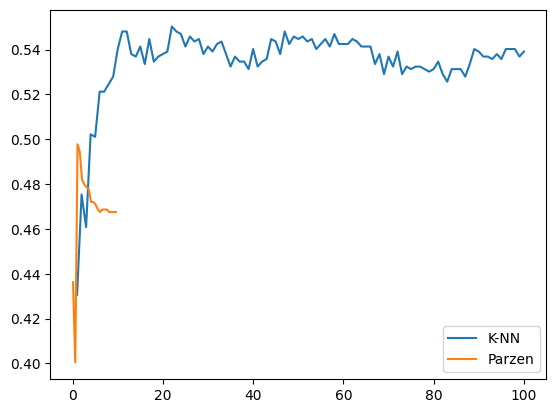

In [202]:
####################################################################
###############   À compléter   ####################################
####################################################################



#######################################################################

# 1. K-nn

k = np.arange(1, 101)
# Trouver la meilleure valeur de k entre 1 et 100
accuracies_knn = []
best_accuracy = 0
for k_value in k:
    neigh = KNeighborsClassifier(n_neighbors=k_value)
    neigh.fit(X_train, y_train)
    y_pred_knn = neigh.predict(X_valid)
    accuracy_knn = accuracy_score(y_valid, y_pred_knn)
    accuracies_knn.append(accuracy_knn)
    # Sauvegarder le meilleur modèle
    if accuracy_knn > best_accuracy:
        best_accuracy = accuracy_knn
        best_k = k_value
        best_predictions = y_pred_knn
        best_model = neigh

# On trouve l'indice du meilleur k
k_index = np.argmax(accuracies_knn)
best_k = k[k_index]
print(f"Best k for K-nn: {best_k}")
print(f"K-nn Accuracy: {accuracies_knn[k_index]:.4f}")
print("Classification Report:\n", classification_report(y_valid, y_pred_knn))
# cm = confusion_matrix(y_valid, y_pred_knn)
#plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
#plt.title('K-nn Confusion Matrix')
#plt.xlabel('Predicted')
#plt.ylabel('Actual')
#plt.show()

# 2. Parzen

radius = np.arange(0.1, 10.1, 0.5)
# trouver la meilleure valeur de radius entre 0.1 et 10.0
accuracies_parzen = []
for radius_value in radius:
    # liste pour stocker les kde de chaque classe
    kdes = []

    # un kde par classe
    for class_idx in range(7):  # Classes 0-6
        mask = (y_train == class_idx)
        if np.sum(mask) > 0:
            kde = KernelDensity(bandwidth=radius_value, kernel='gaussian')
            kde.fit(X_train[mask])
            kdes.append(kde)
        else:
            kdes.append(None)

    # calcul des densités
    log_probs = np.zeros((len(X_valid), 7))
    for class_idx in range(7):
        if kdes[class_idx] is not None:
            log_probs[:, class_idx] = kdes[class_idx].score_samples(X_valid)
        else:
            log_probs[:, class_idx] = -np.inf

    # choisir la classe avec la plus haute densité
    y_pred_parzen = np.argmax(log_probs, axis=1)
    accuracy_parzen = accuracy_score(y_valid, y_pred_parzen)
    accuracies_parzen.append(accuracy_parzen)

# on trouve l'indice du meilleur radius
radius_index = np.argmax(accuracies_parzen)
best_radius = radius[radius_index]
print(f"Best radius for Parzen: {best_radius}")
print(f"Parzen Accuracy: {accuracies_parzen[radius_index]:.4f}")
print("Classification Report:\n", classification_report(y_valid, y_pred_parzen))


# 3. SVM

c_values = [0.01, 0.1, 1, 10, 100]
accuracies_svm = []
for c in c_values:
    # Noyau linéaire comme vu en classe
    svm_model = SVC(kernel='linear', C=c)
    svm_model.fit(X_train, y_train)
    y_pred_svm = svm_model.predict(X_valid)
    accuracy_svm = accuracy_score(y_valid, y_pred_svm)
    accuracies_svm.append(accuracy_svm)
# On trouve l'indice du meilleur c
c_index = np.argmax(accuracies_svm)
best_c = c_values[c_index]
print(f"Best C for SVM: {best_c}")
print(f"SVM Accuracy: {accuracies_svm[c_index]:.4f}")
print("Classification Report:\n", classification_report(y_valid, y_pred_svm))



# 4 Regression Logistique
accuracies_logreg = []
c_values = [0.01, 0.1, 1, 10, 100]
for c in c_values:
    logreg = LogisticRegression(penalty='l2', max_iter=1000, C=c)
    logreg.fit(X_train, y_train)
    y_pred_logreg = logreg.predict(X_valid)
    accuracy_logreg = accuracy_score(y_valid, y_pred_logreg)
    accuracies_logreg.append(accuracy_logreg)
# On trouve l'indice du meilleur c
c_index = np.argmax(accuracies_logreg)
best_c = c_values[c_index]
print(f"Best C for Logistic Regression: {best_c}")
print(f"Logistic Regression Accuracy: {accuracies_logreg[c_index]:.4f}")
print("Classification Report:\n", classification_report(y_valid, y_pred_logreg))
# cm = confusion_matrix(y_valid, y_pred_logreg)
# plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
# plt.title('Logistic Regression Confusion Matrix')
# plt.xlabel('Predicted')
# plt.ylabel('Actual')
# plt.show()
plt.plot(k, accuracies_knn, label='K-NN')
plt.plot(radius, accuracies_parzen, label='Parzen')
plt.legend()
plt.show()


## Évaluer les Modèles

Analysez la performance de votre meilleur modèle (voir README.md pour les directives d'évaluation).

In [ ]:
####################################################################
###############   À compléter   ####################################
####################################################################

# Maintenant on prévoit les y de test
# Charger les données de test
test_df = pd.read_csv('data/test.csv', delimiter=';')

# On retraite les données de la même façon que le prétraitement
num_cols = ['bitterness_IBU', 'diacetyl_concentration', 'lactic_acid', 
                'final_gravity', 'sodium', 'free_CO2', 'dissolved_oxygen', 
                'original_gravity', 'pH', 'gypsum_level', 'alcohol_ABV',
                  'fermentation_strength']

# On encode la variable catégorielle
cat_cols = ['beer_style']

ohe = OneHotEncoder(sparse_output=False)
beer_style_encoded = ohe.fit_transform(test_df[['beer_style']])
cat__test_columns_names = ohe.get_feature_names_out(['beer_style'])

cat_test_df = pd.DataFrame(
    beer_style_encoded,
    columns=cat__test_columns_names,
    index=test_df.index
)

# Standardisation
scaler = StandardScaler()
features_scaled = scaler.fit_transform(test_df[num_cols])
test_df = pd.DataFrame(features_scaled, columns=num_cols, index=test_df.index)

X_test = test_df[['alcohol_ABV', 'diacetyl_concentration', 'sodium']]
X_test = pd.concat([X_test, cat_test_df], axis=1)

# On réentraine le modele sur x train et x valid
final_model = KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(X, y)
y_train_pred = neigh.predict(X)
train_accuracy = accuracy_score(y, y_train_pred)

print("Final Model Training Accuracy: {:.4f}".format(train_accuracy))

prediction = neigh.predict(X_test)

print("Predictions on test data:")
print(prediction)



Final Model Training Accuracy: 0.5509
Predictions on test data:
[6 6 6 6 6 5 5 5 6 5 6 6 5 6 6 6 5 7 6 6 6 6 6 5 5 5 5 6 6 6 6 6 5 5 5 6 6
 6 6 6 6 6 6 6 5 6 6 6 7 7 6 6 6 6 6 5 5 6 6 6 5 6 7 6 6 6 5 6 6 5 6 5 6 5
 5 6 6 5 6 6 6 6 6 6 5 5 6 6 6 5 6 6 5 6 6 6 6 6 6 5 6 5 5 6 6 6 7 6 6 5 6
 6 5 6 6 5 5 6 6 6 6 6 5 6 6 5 5 6 6 6 5 6 5 6 6 6 6 6 6 6 6 6 6 6 6 5 6 5
 5 6 6 6 6 6 6 6 6 5 5 6 5 5 6 6 6 6 6 6 6 6 6 5 6 6 6 5 5 6 5 5 6 5 6 6 6
 6 5 6 7 6 5 6 6 6 6 6 5 6 6 5 5 6 6 6 5 6 6 7 5 6 6 6 5 6 6 5 6 5 6 6 5 5
 6 5 6 6 6 6 6 5 5 5 5 5 6 6 5 6 5 6 6 6 6 6 6 6 6 5 6 6 5 7 5 5 5 5 6 6 5
 6 6 5 5 6 6 7 6 5 7 6 5 6 5 5 5 5 5 6 6 6 6 6 6 6 6 6 6 6 6 5 7 5 6 6 6 6
 6 5 6 6 7 6 6 6 6 6 6 6 5 5 5 6 5 5 5 6 6 6 5 7 6 5 6 6 6 6 5 6 6 6 6 6 5
 6 6 6 5 6 7 5 5 6 6 5 6 6 6 5 6 5 6 5 6 5 6 5 6 6 5 6 5 5 6 6 5 5 5 6 6 6
 6 6 5 5 5 5 5 5 5 5 6 5 6 5 5 6 6 5 6 6 6 6 5 5 6 6 6 6 6 6 6 5 6 5 5 6 6
 6 5 6 5 5 6 6 5 6 6 5 6 5 6 6 6 5 5 6 6 6 5 5 6 5 5 6 5 6 6 6 7 6 6 6 6 6
 6 5 6 6 6 6 6 5 6 6 5 6 5 6 6 6 6 6

## Générer les Prédictions pour la Soumission Kaggle

Créez un fichier CSV avec les colonnes : `id` et `quality` (voir README.md pour les détails du format).

In [ ]:

####################################################################
###############   À compléter   ####################################
####################################################################

---
Bonne chance pour la compétition ! 🍺
